# Hybrid AI — Tối Ưu Lịch Trình Xe Buýt TP.HCM
## Spatio-Temporal GNN × Genetic Algorithm × Tabu Search

**Pipeline:**
1. **Dữ liệu** — đọc 8 bảng CSV có sẵn trong `data/` (hoặc sinh một lần nếu thiếu / `REGENERATE_DATA=True`)
2. **EDA** — phân tích nhu cầu, tốc độ, mạng lưới
3. **GNN** — huấn luyện GCN+GRU dự báo nhu cầu theo không-thời gian
4. **Lan truyền ùn tắc** — khuếch tán stress trên đồ thị (cùng topology GCN)
5. **Tối ưu lịch khởi hành** — GA + Tabu trên ma trận slot (không headway cố định)
6. **Đánh giá** — so sánh trước/sau, biểu đồ, bảng lịch

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Thêm thư mục gốc vào path để import utils/models/optimizers
ROOT = os.path.abspath(".")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("✓ Imports OK — root:", ROOT)

✓ Imports OK — root: d:\bus-schedule-optimization


## 1  Cấu hình & Dữ liệu

**Mặc định:** nếu đủ 8 file CSV trong `data/`, notebook **chỉ đọc** (không sinh lại). Đặt `REGENERATE_DATA = True` ở cell cấu hình nếu muốn ghi đè và tạo dataset mới (cùng tham số `CFG`).

In [2]:
# ── Tham số toàn cục ──────────────────────────────────────────────────────────
# Đặt True chỉ khi muốn ghi đè và sinh lại toàn bộ 8 bảng CSV trong data/
REGENERATE_DATA = False

CFG = dict(
    seed            = 42,
    n_days          = 7,       # số ngày mô phỏng (chỉ dùng khi REGENERATE_DATA=True)
    n_buses         = 12,      # đội xe
    trips_per_bus   = 6,       # chuyến / xe / ngày
    freq_min        = 15,      # độ phân giải snapshot (phút)
    base_date       = "2025-09-01",
    gnn_window      = 4,       # look-back GNN (số slot thời gian)
    gnn_epochs      = 20,
    gnn_batch       = 32,
    ga_pop          = 50,
    ga_iter         = 120,
    tabu_iter       = 80,
    slot_minutes    = 30,      # độ phân giải lịch tối ưu
)
DATA_DIR = os.path.join(ROOT, "data")
os.makedirs(DATA_DIR, exist_ok=True)
print("Cấu hình:", CFG)
print("REGENERATE_DATA =", REGENERATE_DATA, "(True = sinh lại CSV)")

Cấu hình: {'seed': 42, 'n_days': 7, 'n_buses': 12, 'trips_per_bus': 6, 'freq_min': 15, 'base_date': '2025-09-01', 'gnn_window': 4, 'gnn_epochs': 20, 'gnn_batch': 32, 'ga_pop': 50, 'ga_iter': 120, 'tabu_iter': 80, 'slot_minutes': 30}
REGENERATE_DATA = False (True = sinh lại CSV)


In [3]:
from utils.network_sim import HCMCBusNetwork

net = HCMCBusNetwork(seed=CFG["seed"], data_dir=DATA_DIR)
print(f"Mạng: {len(net.stops)} trạm  |  {len(net.routes)} tuyến  |  {net.graph.number_of_edges()} đoạn")
print("Tuyến:", net.route_codes)
for code in net.route_codes:
    r = net.routes[code]
    print(f"  [{code}] {r['name']} — {len(r['stops'])} trạm — RTT {net.route_rtt[code]:.0f} ph")

Mạng: 13 trạm  |  4 tuyến  |  17 đoạn
Tuyến: ['01', '19', '52', '65']
  [01] Bến Thành – Gò Vấp — 5 trạm — RTT 144 ph
  [19] Bến Thành – An Sương — 8 trạm — RTT 143 ph
  [52] Bến Thành – Thủ Đức — 4 trạm — RTT 101 ph
  [65] Chợ Lớn – Thủ Đức — 5 trạm — RTT 179 ph


In [4]:
from utils.schema_sim import (
    SchemaSimulator,
    all_generated_tables_exist,
    load_generated_tables,
    build_feature_tensor_from_snapshots,
)

schema_sim = SchemaSimulator(net, seed=CFG["seed"])

if REGENERATE_DATA or not all_generated_tables_exist(DATA_DIR):
    if REGENERATE_DATA:
        print("[schema_sim] REGENERATE_DATA=True — sinh lại toàn bộ 8 bảng…")
    else:
        print("[schema_sim] Thiếu file trong data/ — sinh dữ liệu lần đầu…")
    tables = schema_sim.generate_all(
        n_days                = CFG["n_days"],
        n_buses               = CFG["n_buses"],
        trips_per_bus_per_day = CFG["trips_per_bus"],
        freq_minutes          = CFG["freq_min"],
        base_date             = CFG["base_date"],
        out_dir               = DATA_DIR,
    )
else:
    tables = load_generated_tables(DATA_DIR)

for name, df in tables.items():
    print(f"  {name:35s}  {len(df):>6,} dòng  ×  {len(df.columns)} cột")

[schema_sim] Loaded 8 tables from d:\bus-schedule-optimization\data (skip generate)
  route_master                              4 dòng  ×  6 cột
  stops                                    13 dòng  ×  5 cột
  network_segments                         18 dòng  ×  7 cột
  buses                                    12 dòng  ×  4 cột
  trips                                   504 dòng  ×  6 cột
  stop_times                            2,772 dòng  ×  5 cột
  spatiotemporal_snapshots             14,784 dòng  ×  8 cột
  operation_logs                        2,772 dòng  ×  8 cột


## 2  Khám phá dữ liệu (EDA)

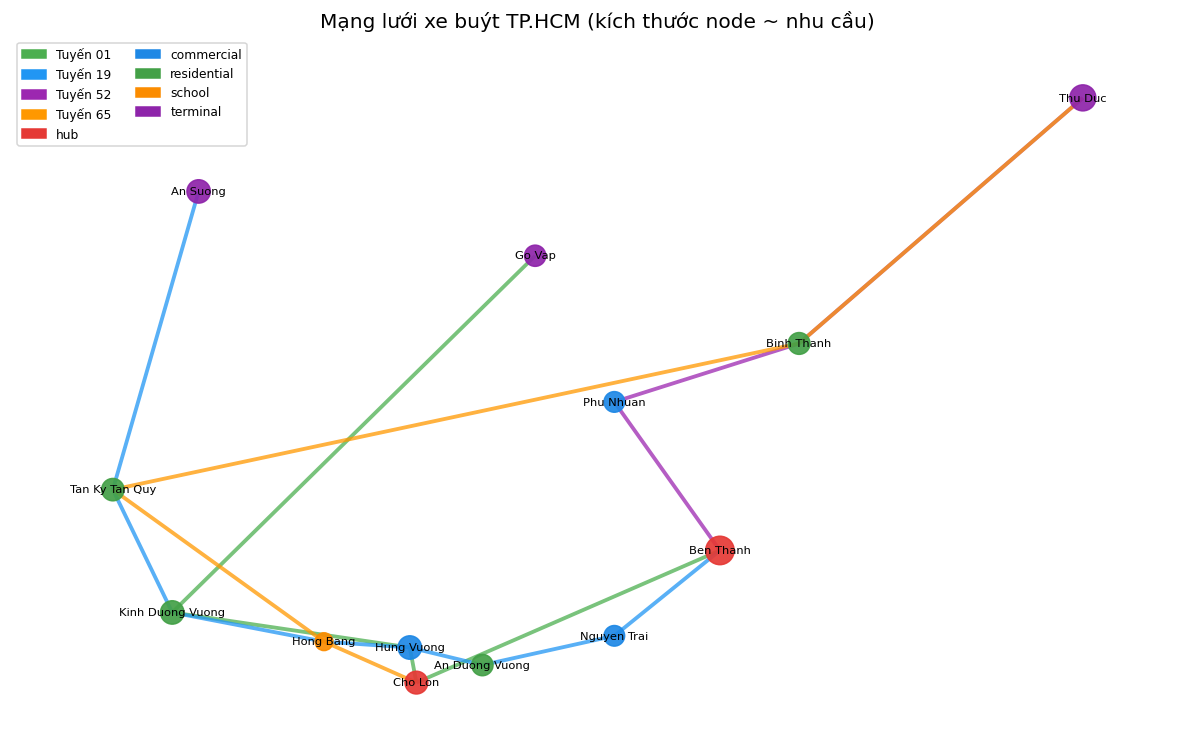

In [5]:
# ── 2.1  Đồ thị mạng lưới ──────────────────────────────────────────────────
ROUTE_COLORS = {code: net.routes[code]["color"] for code in net.route_codes}
CAT_COLORS   = {"hub": "#e53935", "commercial": "#1e88e5",
                "residential": "#43a047", "school": "#fb8c00", "terminal": "#8e24aa"}

pos = {s.id: (s.lon, s.lat) for s in net.stops}
node_colors = [CAT_COLORS.get(s.category, "#888") for s in net.stops]
node_sizes  = [80 + net.demand[s.id] * 2.5 for s in net.stops]

fig, ax = plt.subplots(figsize=(11, 7))
nx.draw_networkx_nodes(net.graph, pos, node_color=node_colors,
                       node_size=node_sizes, ax=ax, alpha=0.92)
nx.draw_networkx_labels(net.graph, pos,
                        labels={s.id: s.name for s in net.stops},
                        font_size=7.5, ax=ax)

for code in net.route_codes:
    ids   = net.routes[code]["stops"]
    edges = list(zip(ids[:-1], ids[1:]))
    nx.draw_networkx_edges(net.graph, pos, edgelist=edges,
                           edge_color=ROUTE_COLORS[code], width=2.5,
                           alpha=0.75, ax=ax,
                           connectionstyle=f"arc3,rad={0.07 * net.route_codes.index(code)}")

patches = [mpatches.Patch(color=c, label=f"Tuyến {k}") for k, c in ROUTE_COLORS.items()]
patches += [mpatches.Patch(color=c, label=k) for k, c in CAT_COLORS.items()]
ax.legend(handles=patches, fontsize=8, loc="upper left", ncol=2)
ax.set_title("Mạng lưới xe buýt TP.HCM (kích thước node ~ nhu cầu)")
ax.axis("off")
plt.tight_layout()
plt.show()

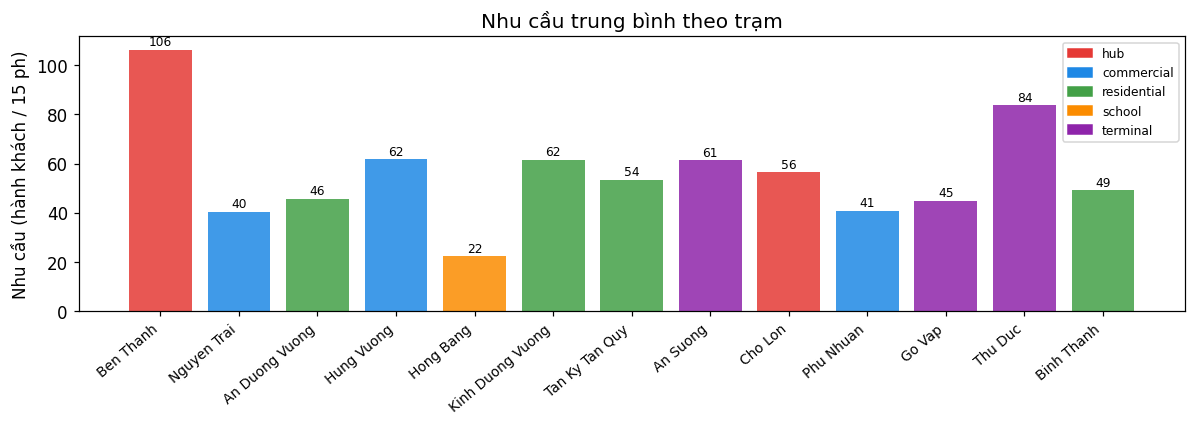

In [6]:
# ── 2.2  Nhu cầu trung bình theo trạm ────────────────────────────────────────
stop_names = [net.stop_map[i].name for i in sorted(net.demand)]
demands    = [net.demand[i] for i in sorted(net.demand)]
cats       = [net.stop_map[i].category for i in sorted(net.demand)]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(stop_names, demands,
              color=[CAT_COLORS.get(c, "#888") for c in cats], alpha=0.85)
ax.set_xticklabels(stop_names, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Nhu cầu (hành khách / 15 ph)")
ax.set_title("Nhu cầu trung bình theo trạm")
for bar, d in zip(bars, demands):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{d:.0f}", ha="center", va="bottom", fontsize=8)
patches = [mpatches.Patch(color=c, label=k) for k, c in CAT_COLORS.items()]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.show()

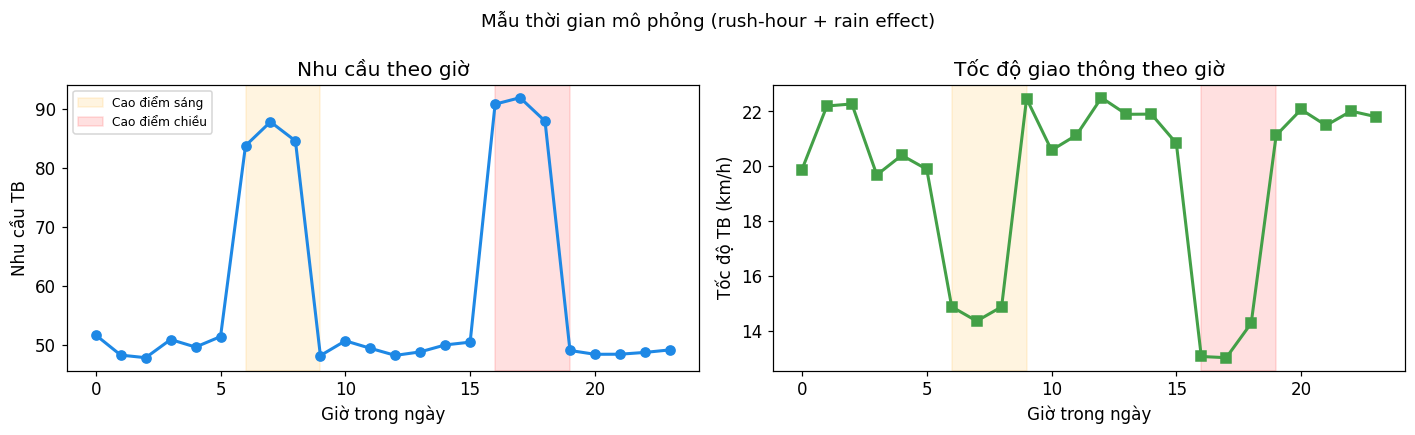

Tỷ lệ snapshot có mưa: 35.7%


In [7]:
# ── 2.3  Nhu cầu & tốc độ theo giờ trong ngày (SpatioTemporal_Snapshots) ───
snap = tables["spatiotemporal_snapshots"].copy()
snap["hour"] = pd.to_datetime(snap["timestamp"]).dt.hour

by_hour = snap.groupby("hour")[["demand_value", "traffic_speed"]].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(by_hour.index, by_hour["demand_value"], "o-", color="#1e88e5", linewidth=2)
ax1.axvspan(6, 9,   alpha=0.12, color="orange", label="Cao điểm sáng")
ax1.axvspan(16, 19, alpha=0.12, color="red",    label="Cao điểm chiều")
ax1.set_xlabel("Giờ trong ngày"); ax1.set_ylabel("Nhu cầu TB")
ax1.set_title("Nhu cầu theo giờ"); ax1.legend(fontsize=8)

ax2.plot(by_hour.index, by_hour["traffic_speed"], "s-", color="#43a047", linewidth=2)
ax2.axvspan(6, 9,   alpha=0.12, color="orange")
ax2.axvspan(16, 19, alpha=0.12, color="red")
ax2.set_xlabel("Giờ trong ngày"); ax2.set_ylabel("Tốc độ TB (km/h)")
ax2.set_title("Tốc độ giao thông theo giờ")

plt.suptitle("Mẫu thời gian mô phỏng (rush-hour + rain effect)", fontsize=12)
plt.tight_layout()
plt.show()

rain_pct = snap["is_rain"].mean() * 100
print(f"Tỷ lệ snapshot có mưa: {rain_pct:.1f}%")

In [8]:
# ── 2.4  Thống kê nhanh các bảng ────────────────────────────────────────────
print("=== Route_Master ===")
display(tables["route_master"])

print("\n=== Stops ===")
display(tables["stops"])

print("\n=== Route_Stops (lộ trình) ===")
display(pd.read_csv(os.path.join(DATA_DIR, "route_stops.csv")))

print("\n=== Buses ===")
display(tables["buses"])

print("\n=== Trips (5 dòng đầu) ===")
display(tables["trips"].head())

print("\n=== Stop_Times (5 dòng đầu) ===")
display(tables["stop_times"].head())

print("\n=== Operation_Logs (5 dòng đầu) ===")
display(tables["operation_logs"].head())

=== Route_Master ===


,route_code,route_name,total_distance_km,service_start,service_end,color
0,1,Bến Thành – Gò Vấp,19.34,05:00,19:00,#4CAF50
1,19,Bến Thành – An Sương,18.26,05:00,19:00,#2196F3
2,52,Bến Thành – Thủ Đức,13.20,05:00,19:00,#9C27B0
3,65,Chợ Lớn – Thủ Đức,24.57,05:00,19:00,#FF9800



=== Stops ===


,stop_id,stop_name,stop_category,latitude,longitude
0,0,Ben Thanh,hub,10.77,106.70
1,1,Nguyen Trai,commercial,10.76,106.68
2,2,An Duong Vuong,residential,10.75,106.66
3,3,Hung Vuong,commercial,10.76,106.65
4,4,Hong Bang,school,10.76,106.64
5,5,Kinh Duong Vuong,residential,10.76,106.61
6,6,Tan Ky Tan Quy,residential,10.78,106.61
7,7,An Suong,terminal,10.83,106.62
8,8,Cho Lon,hub,10.75,106.65
9,9,Phu Nhuan,commercial,10.80,106.68



=== Route_Stops (lộ trình) ===


...

,trip_id,route_code,bus_id,direction,start_time,end_time
0,TRIP-2025-09-01-BUS-001-01,1,BUS-001,outbound,2025-09-01T05:32:41,2025-09-01T07:56:41
1,TRIP-2025-09-01-BUS-001-02,1,BUS-001,outbound,2025-09-01T07:28:10,2025-09-01T09:52:10
2,TRIP-2025-09-01-BUS-001-03,1,BUS-001,outbound,2025-09-01T09:59:36,2025-09-01T12:23:36
3,TRIP-2025-09-01-BUS-001-04,1,BUS-001,outbound,2025-09-01T12:01:50,2025-09-01T14:25:50
4,TRIP-2025-09-01-BUS-001-05,1,BUS-001,outbound,2025-09-01T14:26:28,2025-09-01T16:50:28



=== Stop_Times (5 dòng đầu) ===


,trip_id,stop_id,arrival_time,departure_time,stop_sequence
0,TRIP-2025-09-01-BUS-001-01,0,2025-09-01T05:32:41,2025-09-01T05:33:31,1
1,TRIP-2025-09-01-BUS-001-01,8,2025-09-01T05:52:15,2025-09-01T05:52:47,2
2,TRIP-2025-09-01-BUS-001-01,3,2025-09-01T05:55:03,2025-09-01T05:55:50,3
3,TRIP-2025-09-01-BUS-001-01,5,2025-09-01T06:09:08,2025-09-01T06:09:56,4
4,TRIP-2025-09-01-BUS-001-01,10,2025-09-01T06:40:08,2025-09-01T06:40:44,5



=== Operation_Logs (5 dòng đầu) ===


,trip_id,bus_id,route_code,stop_id,actual_arrival,actual_departure,boarding_count,dwell_time_sec
0,TRIP-2025-09-01-BUS-001-01,BUS-001,1,0,2025-09-01T05:31:27,2025-09-01T05:32:14,15,47.50
1,TRIP-2025-09-01-BUS-001-01,BUS-001,1,8,2025-09-01T05:54:19,2025-09-01T05:54:40,8,21.10
2,TRIP-2025-09-01-BUS-001-01,BUS-001,1,3,2025-09-01T05:53:39,2025-09-01T05:54:12,0,32.50
3,TRIP-2025-09-01-BUS-001-01,BUS-001,1,5,2025-09-01T06:09:01,2025-09-01T06:09:52,0,50.50
4,TRIP-2025-09-01-BUS-001-01,BUS-001,1,10,2025-09-01T06:39:50,2025-09-01T06:40:23,0,33.50


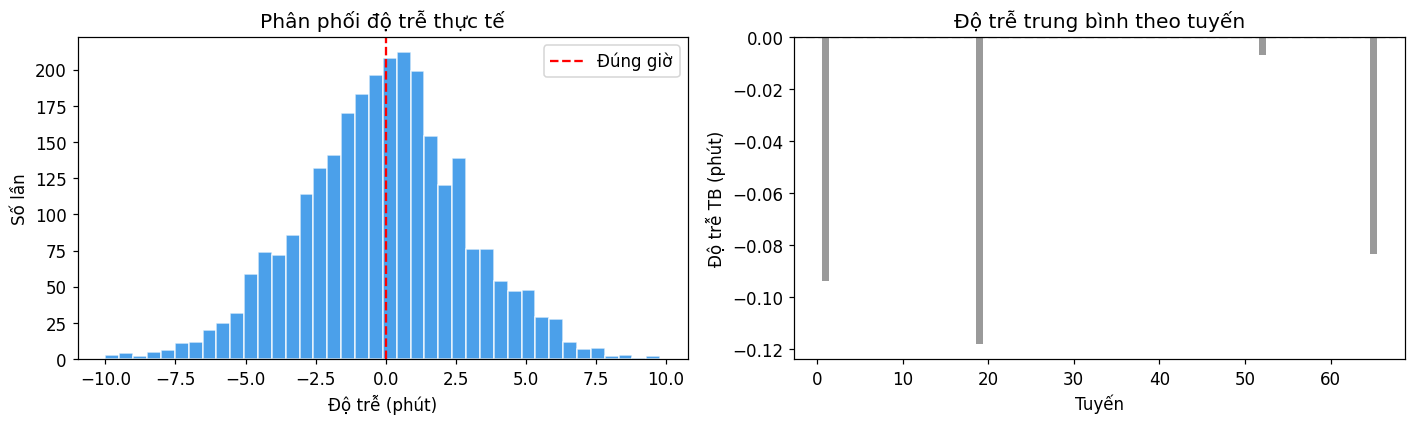

Độ trễ TB toàn mạng: -0.08 phút
Std: 2.91 phút
             count  mean  std    min   25%   50%  75%  max
route_code                                                
1           630.00 -0.09 2.90 -10.27 -1.93 -0.02 1.60 9.43
19         1008.00 -0.12 2.95 -10.23 -2.03 -0.07 1.68 9.80
52          504.00 -0.01 2.97  -8.62 -1.88  0.13 1.95 8.72
65          630.00 -0.08 2.80 -11.73 -1.91 -0.02 1.68 7.47


In [9]:
# ── 2.5  Phân tích độ trễ (Operation_Logs vs Stop_Times) ────────────────────
op  = tables["operation_logs"].copy()
st  = tables["stop_times"].copy()

op["actual_arrival"]   = pd.to_datetime(op["actual_arrival"])
st["arrival_time"]     = pd.to_datetime(st["arrival_time"])

merged = op.merge(st[["trip_id", "stop_id", "arrival_time"]],
                  on=["trip_id", "stop_id"], how="inner")
merged["delay_min"] = (merged["actual_arrival"] - merged["arrival_time"]).dt.total_seconds() / 60

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(merged["delay_min"].clip(-10, 15), bins=40, color="#1e88e5", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Đúng giờ")
axes[0].set_xlabel("Độ trễ (phút)"); axes[0].set_ylabel("Số lần")
axes[0].set_title("Phân phối độ trễ thực tế"); axes[0].legend()

delay_by_route = merged.groupby("route_code")["delay_min"].mean()
axes[1].bar(delay_by_route.index, delay_by_route.values,
            color=[ROUTE_COLORS.get(c, "#888") for c in delay_by_route.index], alpha=0.85)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_xlabel("Tuyến"); axes[1].set_ylabel("Độ trễ TB (phút)")
axes[1].set_title("Độ trễ trung bình theo tuyến")

plt.tight_layout()
plt.show()

print(f"Độ trễ TB toàn mạng: {merged['delay_min'].mean():.2f} phút")
print(f"Std: {merged['delay_min'].std():.2f} phút")
print(merged.groupby("route_code")["delay_min"].describe().round(2))

## 3  Huấn luyện Spatio-Temporal GNN (GCN + GRU)

In [10]:
import tensorflow as tf
from spektral.utils.convolution import gcn_filter
from models.gnn_model import build_model

tf.random.set_seed(CFG["seed"])

stop_ids = net.get_stop_ids()          # [0, 1, ..., 12]
adj      = net.get_adjacency_matrix()  # (N, N)
n_nodes  = len(stop_ids)

X, Y = build_feature_tensor_from_snapshots(
    tables["spatiotemporal_snapshots"], stop_ids, window=CFG["gnn_window"]
)
print(f"GNN tensors — X: {X.shape}  Y: {Y.shape}")
print(f"  Features: [demand, speed, rain]  |  Nodes: {n_nodes}")

GNN tensors — X: (668, 4, 13, 3)  Y: (668, 13)
  Features: [demand, speed, rain]  |  Nodes: 13


In [11]:
split   = int(0.8 * len(X))
X_train = X[:split];  X_val = X[split:] if split < len(X) else X
Y_train = Y[:split];  Y_val = Y[split:] if split < len(Y) else Y

adj_gcn  = gcn_filter(np.asarray(adj, dtype=np.float64))
a_tensor = tf.constant(adj_gcn, dtype=tf.float32)

def make_dataset(x, y, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(len(x), seed=CFG["seed"])
    ds = ds.batch(batch_size)
    ds = ds.map(lambda xi, yi: ((xi, a_tensor), yi))
    return ds.prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, Y_train, CFG["gnn_batch"], shuffle=True)
ds_val   = make_dataset(X_val,   Y_val,   CFG["gnn_batch"])

model = build_model(
    n_nodes    = n_nodes,
    window     = CFG["gnn_window"],
    n_features = X.shape[-1],
)
model.summary()

Model: "spatio_temporal_gnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gcn_encoder_block               │ ?                      │         1,184 │
│ (GcnEncoderBlock)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (1, 64)                │        92,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 13)                │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,573 (369.43 KB)

 Trainable params: 94,573 (369.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 3832.7244 - mae: 56.6636 - val_loss: 3944.4509 - val_mae: 56.9272
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3694.9807 - mae: 55.4200 - val_loss: 3843.2471 - val_mae: 56.0316
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3595.3384 - mae: 54.5075 - val_loss: 3739.9153 - val_mae: 55.0973
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3498.1135 - mae: 53.6149 - val_loss: 3644.8359 - val_mae: 54.2286
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3406.3213 - mae: 52.7470 - val_loss: 3551.7781 - val_mae: 53.3651
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3316.4167 - mae: 51.8915 - val_loss: 3461.6428 - val_mae: 52.5156
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3229.4375 - mae: 51.0466 - val_loss: 3374.0654 - val_mae: 51.6773
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3144.8242 - mae: 50.2105 - val_loss: 3288.7007 - val_mae: 50.8473
Epoch 9

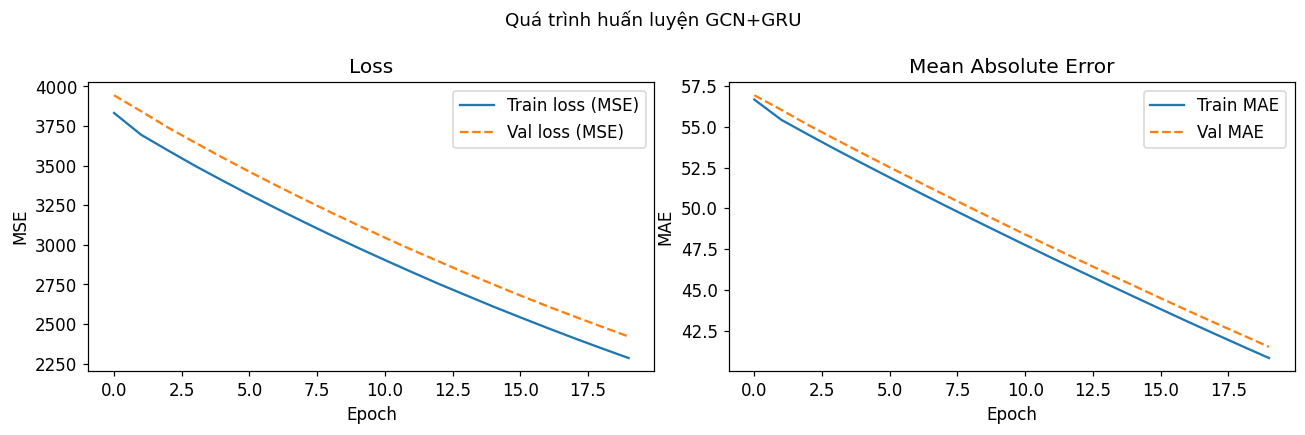

Val MAE cuối: 41.5267


In [12]:
history = model.fit(
    ds_train,
    validation_data = ds_val,
    epochs          = CFG["gnn_epochs"],
    verbose         = 1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["loss"],     label="Train loss (MSE)")
ax1.plot(history.history["val_loss"], label="Val loss (MSE)", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE"); ax1.set_title("Loss")
ax1.legend()

ax2.plot(history.history["mae"],     label="Train MAE")
ax2.plot(history.history["val_mae"], label="Val MAE", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MAE"); ax2.set_title("Mean Absolute Error")
ax2.legend()

plt.suptitle("Quá trình huấn luyện GCN+GRU", fontsize=12)
plt.tight_layout()
plt.show()

final_val_mae = history.history["val_mae"][-1]
print(f"Val MAE cuối: {final_val_mae:.4f}")

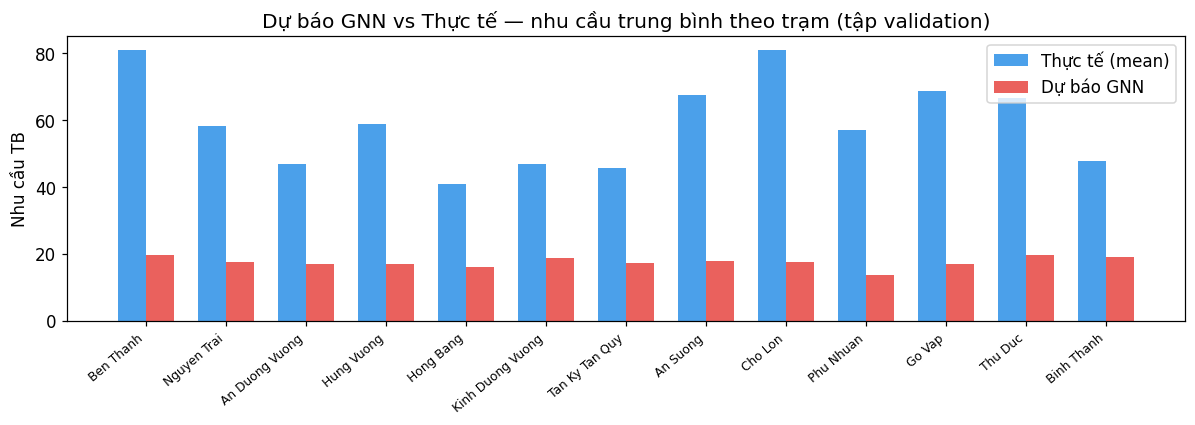


Nhu cầu dự báo theo trạm:
  Ben Thanh               19.5
  Nguyen Trai             17.5
  An Duong Vuong          17.0
  Hung Vuong              16.9
  Hong Bang               15.9
  Kinh Duong Vuong        18.7
  Tan Ky Tan Quy          17.2
  An Suong                17.8
  Cho Lon                 17.6
  Phu Nhuan               13.6
  Go Vap                  16.8
  Thu Duc                 19.6
  Binh Thanh              18.9


In [13]:
preds              = model.predict(ds_val, verbose=0)
avg_predicted_dem  = np.mean(preds, axis=0)     # (N,)
speed_mean_per_stop = np.mean(X_val[:, :, :, 1], axis=(0, 1))

# Dự báo vs thực tế (tập val)
actual_mean = np.mean(Y_val, axis=0)            # (N,)

fig, ax = plt.subplots(figsize=(11, 4))
x_idx = np.arange(n_nodes)
width = 0.35
ax.bar(x_idx - width/2, actual_mean,      width, label="Thực tế (mean)", alpha=0.8, color="#1e88e5")
ax.bar(x_idx + width/2, avg_predicted_dem, width, label="Dự báo GNN",    alpha=0.8, color="#e53935")
ax.set_xticks(x_idx)
ax.set_xticklabels([net.stop_map[i].name for i in stop_ids], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Nhu cầu TB")
ax.set_title("Dự báo GNN vs Thực tế — nhu cầu trung bình theo trạm (tập validation)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nNhu cầu dự báo theo trạm:")
for sid, d in zip(stop_ids, avg_predicted_dem):
    print(f"  {net.stop_map[sid].name:<22}  {d:.1f}")

## 4  Lan truyền ùn tắc trên đồ thị (GNN-aligned Congestion Propagation)

**Ý tưởng:** Dùng cùng đồ thị G với GCN, tính stress cục bộ tại mỗi nút `stress = demand_pred × slowness`, rồi khuếch tán dọc cạnh qua `h ← α·(P@h) + (1-α)·h₀` (random-walk diffusion) — giống một bước message passing nhưng trên numpy. Kết quả: trọng số chờ `wait_weight` cho mỗi trạm, được đưa vào hàm mục tiêu optimizer.

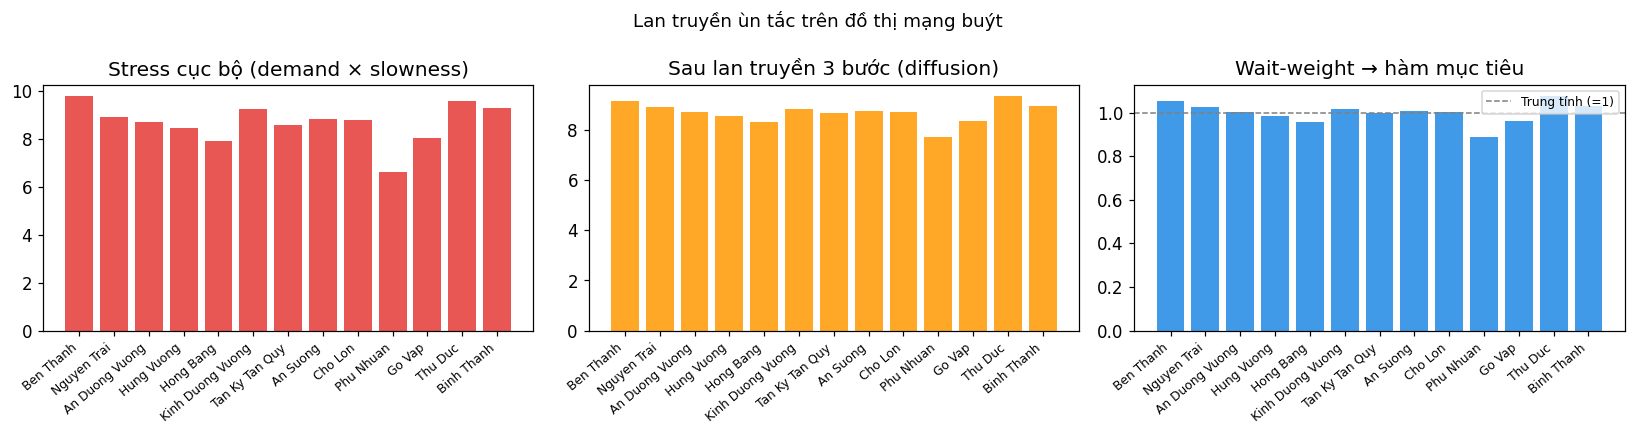

Wait-weights (mean=1 by design): {'Ben Thanh': 1.052, 'Nguyen Trai': 1.027, 'An Duong Vuong': 1.003, 'Hung Vuong': 0.984, 'Hong Bang': 0.955, 'Kinh Duong Vuong': 1.019, 'Tan Ky Tan Quy': 0.996, 'An Suong': 1.008, 'Cho Lon': 1.005, 'Phu Nhuan': 0.887, 'Go Vap': 0.961, 'Thu Duc': 1.075, 'Binh Thanh': 1.028}


In [14]:
from utils.gnn_propagation import (
    local_congestion_stress,
    propagate_stress,
    stress_to_wait_weights,
    build_wait_weights_for_stops,
)

local_stress = local_congestion_stress(avg_predicted_dem, speed_mean_per_stop)
prop_stress  = propagate_stress(np.asarray(adj, dtype=np.float64), local_stress, steps=3, mix=0.55)
wait_weights_arr = stress_to_wait_weights(prop_stress)

wait_w = {int(sid): float(w) for sid, w in zip(stop_ids, wait_weights_arr)}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def bar_stops(ax, values, title, color):
    ax.bar([net.stop_map[i].name for i in stop_ids], values, color=color, alpha=0.85)
    ax.set_xticklabels([net.stop_map[i].name for i in stop_ids],
                       rotation=40, ha="right", fontsize=8)
    ax.set_title(title)

bar_stops(axes[0], local_stress,      "Stress cục bộ (demand × slowness)",  "#e53935")
bar_stops(axes[1], prop_stress,       "Sau lan truyền 3 bước (diffusion)",   "#ff9800")
bar_stops(axes[2], wait_weights_arr,  "Wait-weight → hàm mục tiêu",         "#1e88e5")
axes[2].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Trung tính (=1)")
axes[2].legend(fontsize=8)

plt.suptitle("Lan truyền ùn tắc trên đồ thị mạng buýt", fontsize=12)
plt.tight_layout()
plt.show()

print("Wait-weights (mean=1 by design):", {net.stop_map[k].name: round(v, 3) for k, v in wait_w.items()})

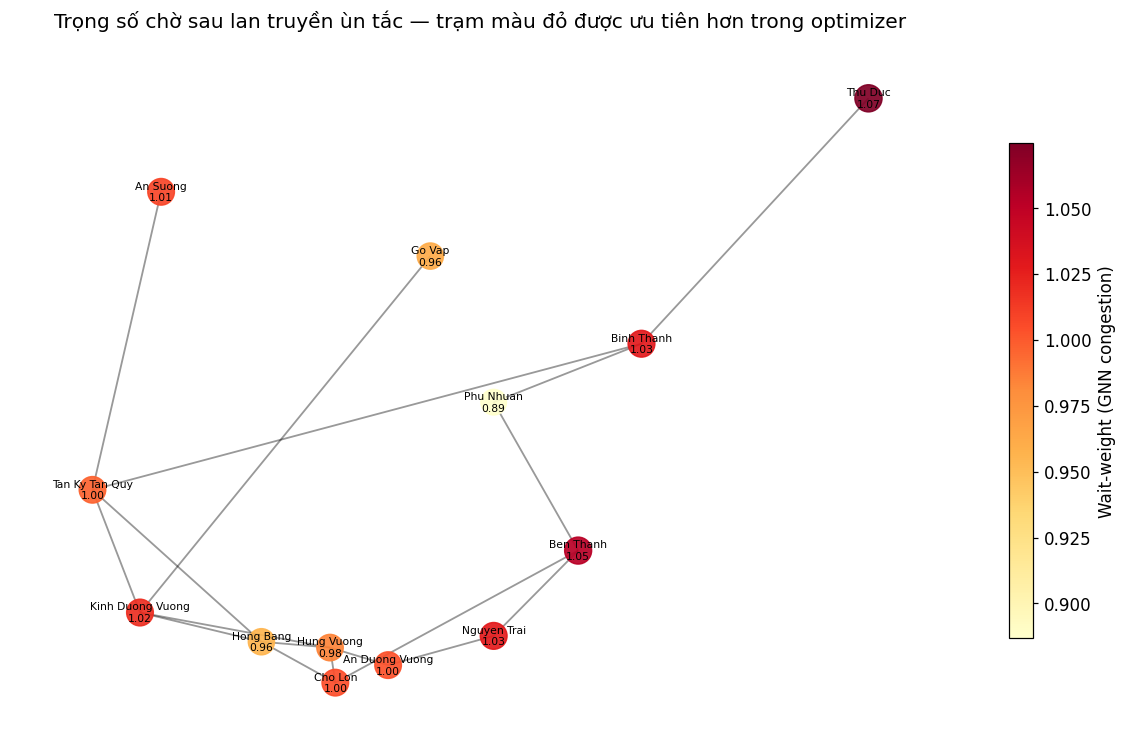

In [15]:
# Visualize: wait_weight lên đồ thị (màu node = mức độ "ưu tiên giảm chờ")
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

cmap = plt.cm.YlOrRd
norm = Normalize(vmin=min(wait_weights_arr), vmax=max(wait_weights_arr))
node_c = [cmap(norm(wait_weights_arr[i])) for i in range(n_nodes)]

fig, ax = plt.subplots(figsize=(11, 7))
nc = nx.draw_networkx_nodes(net.graph, pos, node_color=node_c,
                            node_size=[120 + v * 180 for v in wait_weights_arr],
                            ax=ax, alpha=0.92)
nx.draw_networkx_labels(net.graph, pos,
                        labels={s.id: f"{s.name}\n{wait_weights_arr[i]:.2f}"
                                for i, s in enumerate(sorted(net.stops, key=lambda x: x.id))},
                        font_size=7, ax=ax)
nx.draw_networkx_edges(net.graph, pos, width=1.2, alpha=0.4, ax=ax)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Wait-weight (GNN congestion)", shrink=0.7)
ax.set_title("Trọng số chờ sau lan truyền ùn tắc — trạm màu đỏ được ưu tiên hơn trong optimizer")
ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Gán nhu cầu dự báo + wait_weights vào network object (dùng cho optimizer)
for s in net.stops:
    net.demand[s.id] = float(avg_predicted_dem[stop_ids.index(s.id)])
net.wait_weight_by_stop.update(wait_w)
print("✓ net.demand và net.wait_weight_by_stop đã được cập nhật từ GNN")

✓ net.demand và net.wait_weight_by_stop đã được cập nhật từ GNN


## 5  Tối ưu lịch khởi hành — GA + Tabu Search

**Không dùng headway cố định.** Quyết định nhị phân: mỗi tuyến có/không khởi hành tại từng slot 30 phút trong 05:00–19:00 (28 slot × 4 tuyến = 112 biến). GA tìm vùng nghiệm tốt, Tabu lọc cục bộ.

In [17]:
from optimizers.network_optimizer import (
    SLOT_MINUTES,
    DepartureScheduleOptimizer,
    baseline_schedule_slots,
    compare,
    compute_metrics_from_schedule,
    build_departure_rows_from_schedule,
    n_slots,
)

SLOT_MINUTES_USE = CFG["slot_minutes"]

# Baseline: khởi hành đều đặn mỗi 2 slot (= mỗi 60 phút)
sched_before = baseline_schedule_slots(net, every_k_slots=2)
m_before     = compute_metrics_from_schedule(net, sched_before, SLOT_MINUTES_USE)
print("=== Baseline (trước tối ưu) ===")
print(f"  Chờ TB         : {m_before['avg_wait_min']:.2f} ph")
print(f"  Tổng xe        : {m_before['total_buses']}")
print(f"  Chi phí        : {m_before['total_cost']:.1f}")
print(f"  Objective      : {m_before['objective']:.2f}")
print(f"  Chuyến / tuyến : { {c: m_before['trips_per_route'][c] for c in net.route_codes} }")

=== Baseline (trước tối ưu) ===
  Chờ TB         : 19.29 ph
  Tổng xe        : 11
  Chi phí        : 495.0
  Objective      : 3213.03
  Chuyến / tuyến : {'01': 14, '19': 14, '52': 14, '65': 14}


In [18]:
opt = DepartureScheduleOptimizer(
    net,
    total_fleet  = m_before["total_buses"],
    ga_pop       = CFG["ga_pop"],
    ga_iter      = CFG["ga_iter"],
    tabu_iter    = CFG["tabu_iter"],
    slot_minutes = SLOT_MINUTES_USE,
    rng_seed     = CFG["seed"],
)
sched_after = opt.optimize()
m_after     = compute_metrics_from_schedule(net, sched_after, SLOT_MINUTES_USE)

print("\n=== Sau tối ưu ===")
print(f"  Chờ TB         : {m_after['avg_wait_min']:.2f} ph")
print(f"  Tổng xe        : {m_after['total_buses']}")
print(f"  Chi phí        : {m_after['total_cost']:.1f}")
print(f"  Objective      : {m_after['objective']:.2f}")
print(f"  Chuyến / tuyến : { {c: m_after['trips_per_route'][c] for c in net.route_codes} }")

[network_opt] Phase 1: Genetic Algorithm (departure slots) …
[network_opt] Phase 2: Tabu Search (local flips) …
[network_opt] Best objective = 3188.25

=== Sau tối ưu ===
  Chờ TB         : 19.13 ph
  Tổng xe        : 11
  Chi phí        : 495.0
  Objective      : 3188.23
  Chuyến / tuyến : {'01': 15, '19': 14, '52': 20, '65': 9}


## 6  Đánh giá kết quả

In [19]:
# ── 6.1  Bảng so sánh tổng thể ────────────────────────────────────────────
comp = compare(m_before, m_after)

def pct_fmt(p):
    sign = "+" if p > 0 else ""
    color = "\033[92m" if p < 0 else ("\033[91m" if p > 0 else "")
    reset = "\033[0m"
    return f"{color}{sign}{p:.1f}%{reset}"

rows_comp = [
    ("Thời gian chờ TB (ph)", m_before["avg_wait_min"],  m_after["avg_wait_min"],  comp["wait"]["pct"]),
    ("Chi phí vận hành",      m_before["total_cost"],    m_after["total_cost"],    comp["cost"]["pct"]),
    ("Tổng số xe",            m_before["total_buses"],   m_after["total_buses"],   comp["buses"]["pct"]),
    ("Objective",             m_before["objective"],     m_after["objective"],     comp["objective"]["pct"]),
]
df_comp = pd.DataFrame(rows_comp, columns=["Chỉ số", "Trước", "Sau", "% Thay đổi"])
display(df_comp)

for _, r in df_comp.iterrows():
    print(f"  {r['Chỉ số']:<28}  {r['Trước']:>10.2f}  →  {r['Sau']:>10.2f}  ({pct_fmt(r['% Thay đổi'])})")

,Chỉ số,Trước,Sau,% Thay đổi
0,Thời gian chờ TB (ph),19.29,19.13,-0.80
1,Chi phí vận hành,495.00,495.00,0.00
2,Tổng số xe,11.00,11.00,0.00
3,Objective,3213.03,3188.23,-0.80


  Thời gian chờ TB (ph)              19.29  →       19.13  (-0.8%)
  Chi phí vận hành                  495.00  →      495.00  (0.0%)
  Tổng số xe                         11.00  →       11.00  (0.0%)
  Objective                        3213.03  →     3188.23  (-0.8%)


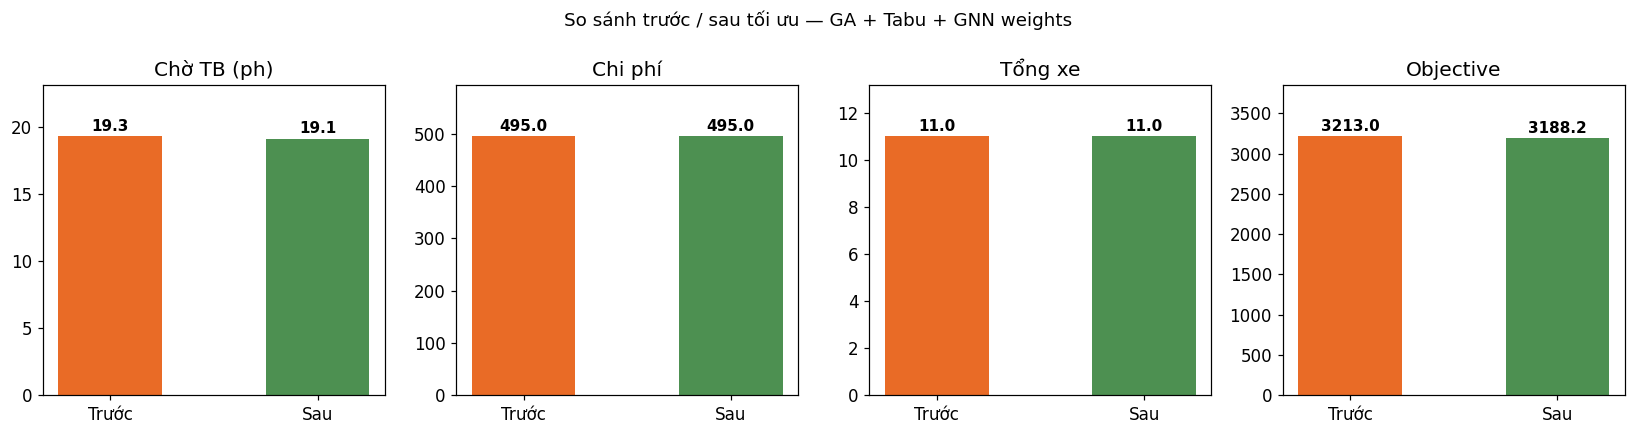

In [20]:
# ── 6.2  So sánh chỉ số trực quan ──────────────────────────────────────────
metrics = ["avg_wait_min", "total_cost", "total_buses", "objective"]
labels  = ["Chờ TB (ph)", "Chi phí", "Tổng xe", "Objective"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, key, lbl in zip(axes, metrics, labels):
    bef = m_before[key]; aft = m_after[key]
    bars = ax.bar(["Trước", "Sau"], [bef, aft],
                  color=["#e65100", "#2e7d32"], alpha=0.85, width=0.5)
    for bar, val in zip(bars, [bef, aft]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(lbl)
    ax.set_ylim(0, max(bef, aft) * 1.2)

plt.suptitle("So sánh trước / sau tối ưu — GA + Tabu + GNN weights", fontsize=12)
plt.tight_layout()
plt.show()

,Tuyến,Tên,Chuyến/ngày trước,Chuyến/ngày sau,Xe trước,Xe sau,Wait-cost trước,Wait-cost sau
0,01,Bến Thành – Gò Vấp,14,15,3,3,1457.50,1420.90
1,19,Bến Thành – An Sương,14,14,3,3,2702.20,2754.60
2,52,Bến Thành – Thủ Đức,14,20,2,3,1135.50,1011.00
3,65,Chợ Lớn – Thủ Đức,14,9,3,2,1322.30,1460.80


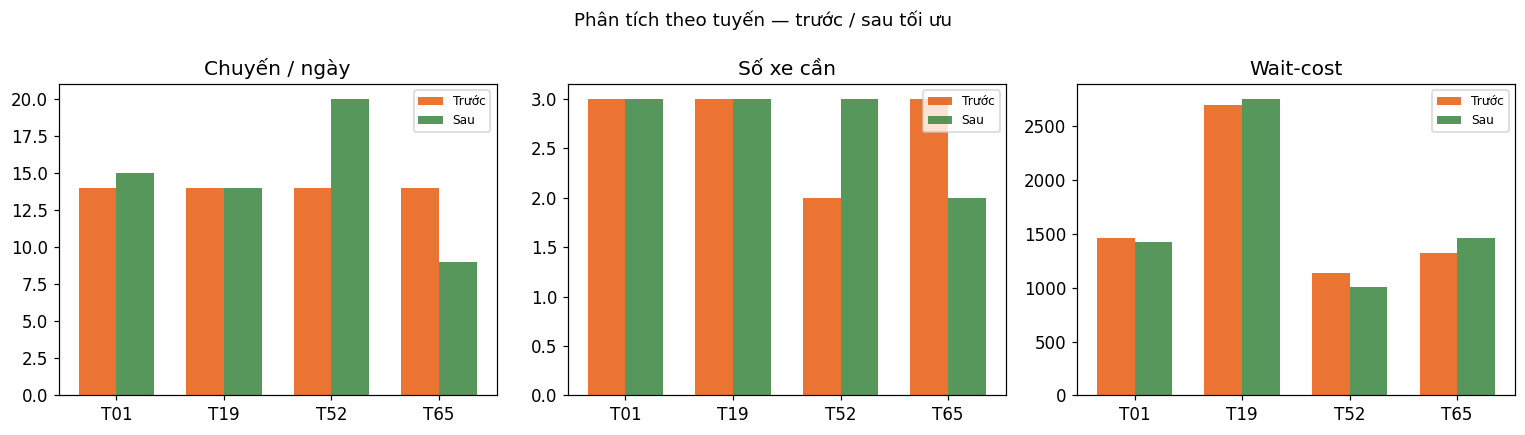

In [21]:
# ── 6.3  So sánh theo từng tuyến ────────────────────────────────────────────
route_df = pd.DataFrame([
    {
        "Tuyến": code,
        "Tên": net.routes[code]["name"],
        "Chuyến/ngày trước": m_before["trips_per_route"][code],
        "Chuyến/ngày sau":   m_after["trips_per_route"][code],
        "Xe trước":          m_before["buses"][code],
        "Xe sau":            m_after["buses"][code],
        "Wait-cost trước":   round(m_before["per_route_wait"][code], 1),
        "Wait-cost sau":     round(m_after["per_route_wait"][code], 1),
        "Màu":               net.routes[code]["color"],
    }
    for code in net.route_codes
])
display(route_df.drop(columns=["Màu"]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.arange(len(net.route_codes)); w = 0.35
colors = [net.routes[c]["color"] for c in net.route_codes]

for ax, (bef_col, aft_col, title) in zip(axes, [
    ("Chuyến/ngày trước", "Chuyến/ngày sau",  "Chuyến / ngày"),
    ("Xe trước",          "Xe sau",            "Số xe cần"),
    ("Wait-cost trước",   "Wait-cost sau",     "Wait-cost"),
]):
    ax.bar(x - w/2, route_df[bef_col], w, color="#e65100", alpha=0.8, label="Trước")
    ax.bar(x + w/2, route_df[aft_col], w, color="#2e7d32", alpha=0.8, label="Sau")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T{c}" for c in net.route_codes])
    ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle("Phân tích theo tuyến — trước / sau tối ưu", fontsize=12)
plt.tight_layout()
plt.show()

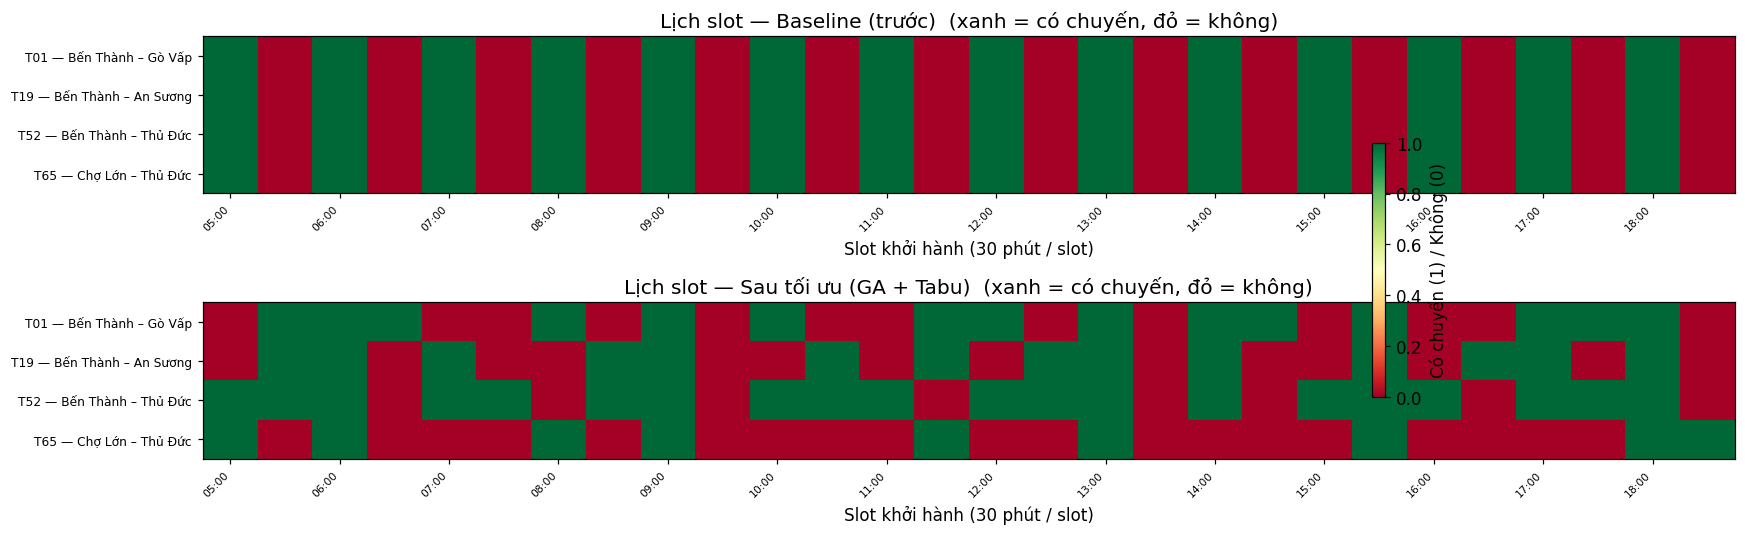

In [22]:
# ── 6.4  Heatmap ma trận lịch trước / sau ────────────────────────────────────
from utils.schema_sim import SERVICE_START

service_start_h = SERVICE_START.hour + SERVICE_START.minute / 60
slot_labels = [
    f"{int(service_start_h + i * SLOT_MINUTES_USE / 60):02d}:{int((service_start_h * 60 + i * SLOT_MINUTES_USE) % 60):02d}"
    for i in range(n_slots())
]
route_labels = [f"T{c} — {net.routes[c]['name']}" for c in net.route_codes]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5))

for ax, sched, title in [(ax1, sched_before, "Baseline (trước)"),
                          (ax2, sched_after,  "Sau tối ưu (GA + Tabu)")]:
    im = ax.imshow(sched.astype(float), aspect="auto", cmap="RdYlGn",
                   vmin=0, vmax=1, interpolation="nearest")
    ax.set_yticks(range(len(net.route_codes)))
    ax.set_yticklabels(route_labels, fontsize=8)
    ax.set_xticks(range(0, n_slots(), 2))
    ax.set_xticklabels(slot_labels[::2], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"Lịch slot — {title}  (xanh = có chuyến, đỏ = không)")
    ax.set_xlabel("Slot khởi hành (30 phút / slot)")

plt.colorbar(im, ax=[ax1, ax2], label="Có chuyến (1) / Không (0)", shrink=0.6)
plt.tight_layout()
plt.show()

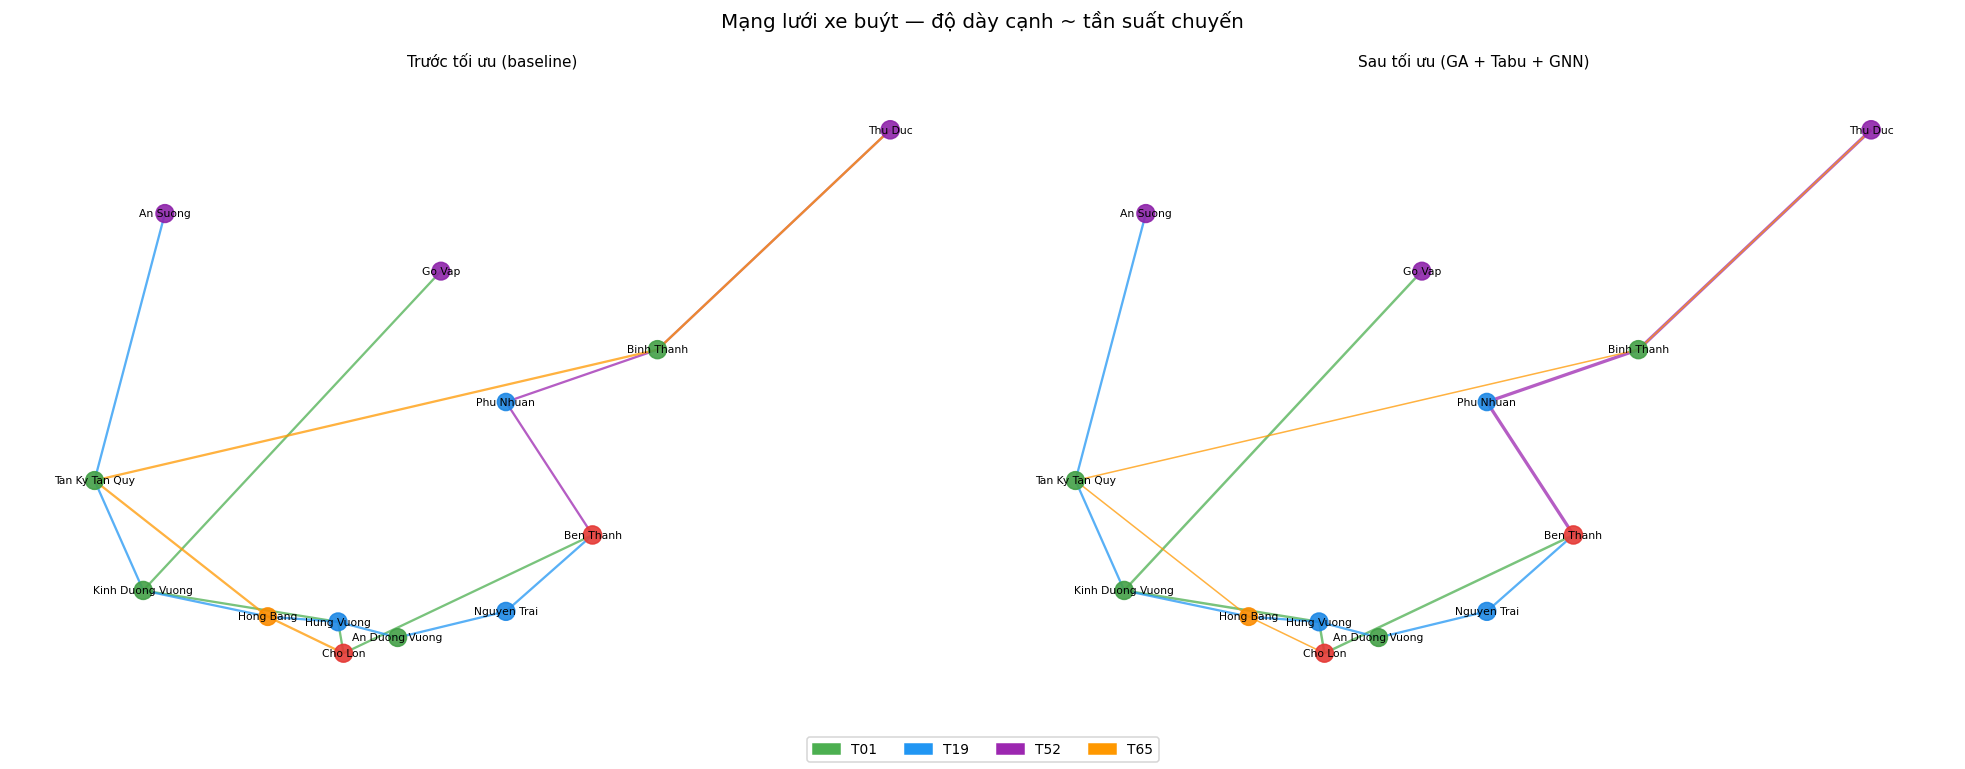

In [23]:
# ── 6.5  Đồ thị mạng trước / sau (kích thước cạnh ~ tần suất chuyến) ────────
def draw_schedule_graph(ax, schedule, title):
    span_h = 14.0  # 05:00–19:00
    rows_t = schedule.sum(axis=1)  # chuyến / ngày / tuyến

    node_c_list = [CAT_COLORS.get(s.category, "#888") for s in net.stops]
    ww_arr = np.array([net.wait_weight_by_stop.get(s.id, 1.0) for s in net.stops])
    node_s  = [80 + net.demand[s.id] * 2 + ww_arr[i] * 20
               for i, s in enumerate(net.stops)]

    nx.draw_networkx_nodes(net.graph, pos, node_color=node_c_list,
                           node_size=node_s, ax=ax, alpha=0.9)
    nx.draw_networkx_labels(net.graph, pos,
                            labels={s.id: s.name for s in net.stops},
                            font_size=7, ax=ax)
    for ri, code in enumerate(net.route_codes):
        trips      = int(rows_t[ri])
        freq       = trips / span_h
        edge_width = max(1.0, min(12.0, freq * 1.5))
        ids = net.routes[code]["stops"]
        edges = list(zip(ids[:-1], ids[1:]))
        rad = 0.07 * net.route_codes.index(code)
        nx.draw_networkx_edges(net.graph, pos, edgelist=edges,
                               edge_color=ROUTE_COLORS[code],
                               width=edge_width, alpha=0.75, ax=ax,
                               connectionstyle=f"arc3,rad={rad}",
                               label=f"T{code} ({trips} ch/ngày)")

    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
draw_schedule_graph(ax1, sched_before, "Trước tối ưu (baseline)")
draw_schedule_graph(ax2, sched_after,  "Sau tối ưu (GA + Tabu + GNN)")

handles = [mpatches.Patch(color=c, label=f"T{k}") for k, c in ROUTE_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9)
plt.suptitle("Mạng lưới xe buýt — độ dày cạnh ~ tần suất chuyến", fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [24]:
# ── 6.6  Bảng lịch khởi hành sau tối ưu ─────────────────────────────────────
departure_rows = build_departure_rows_from_schedule(net, sched_after, SLOT_MINUTES_USE)
df_sched = pd.DataFrame(departure_rows)[[
    "departure_time", "route_code", "route_name", "first_stop_name",
    "trip_seq", "gap_from_prev_min", "rtt_min", "buses_on_route",
]]
df_sched.columns = ["Giờ xuất bến", "Tuyến", "Tên tuyến", "Trạm đầu",
                    "STT", "Khoảng cách (ph)", "RTT (ph)", "Số xe/tuyến"]
print(f"Tổng {len(df_sched)} chuyến tối ưu  |  Slot = {SLOT_MINUTES_USE} phút  |  05:00–19:00")
display(df_sched)

Tổng 58 chuyến tối ưu  |  Slot = 30 phút  |  05:00–19:00


,Giờ xuất bến,Tuyến,Tên tuyến,Trạm đầu,STT,Khoảng cách (ph),RTT (ph),Số xe/tuyến
0,05:00,52,Bến Thành – Thủ Đức,Ben Thanh,1,NaN,101.00,3
1,05:00,65,Chợ Lớn – Thủ Đức,Cho Lon,1,NaN,178.80,2
2,05:30,01,Bến Thành – Gò Vấp,Ben Thanh,1,NaN,144.00,3
3,05:30,19,Bến Thành – An Sương,Ben Thanh,1,NaN,142.80,3
4,05:30,52,Bến Thành – Thủ Đức,Ben Thanh,2,30.00,101.00,3
5,06:00,01,Bến Thành – Gò Vấp,Ben Thanh,2,30.00,144.00,3
6,06:00,19,Bến Thành – An Sương,Ben Thanh,2,30.00,142.80,3
7,06:00,52,Bến Thành – Thủ Đức,Ben Thanh,3,30.00,101.00,3
8,06:00,65,Chợ Lớn – Thủ Đức,Cho Lon,2,60.00,178.80,2
9,06:30,01,Bến Thành – Gò Vấp,Ben Thanh,3,30.00,144.00,3


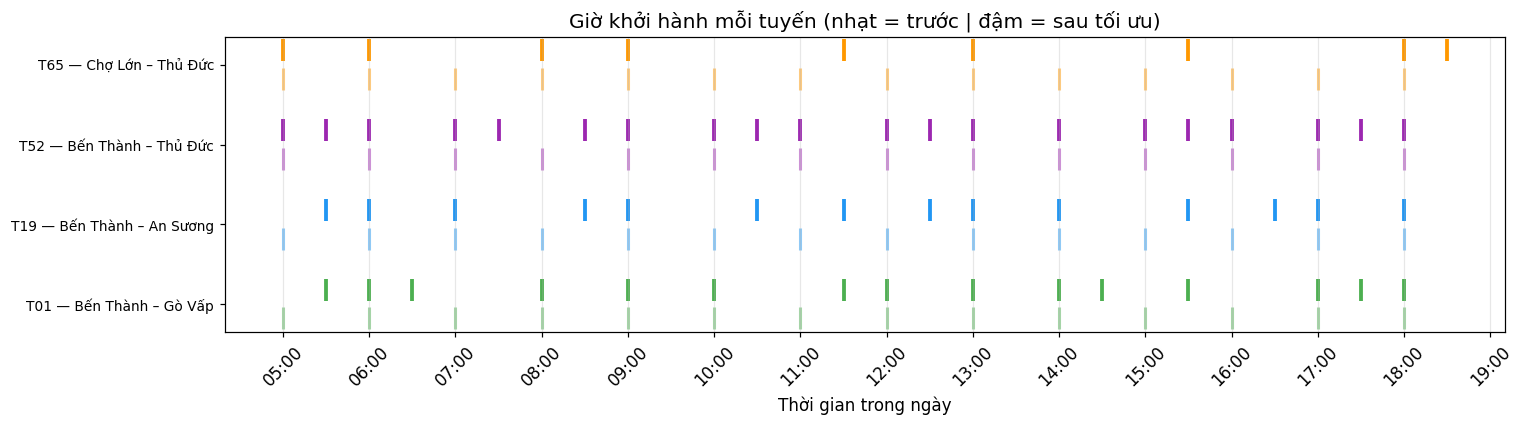

In [25]:
# ── 6.7  Thời gian khởi hành theo tuyến (scatter plot) ──────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

for ri, code in enumerate(net.route_codes):
    slots_b = [k * SLOT_MINUTES_USE for k in range(n_slots()) if sched_before[ri, k]]
    slots_a = [k * SLOT_MINUTES_USE for k in range(n_slots()) if sched_after[ri, k]]

    color = ROUTE_COLORS[code]
    ax.scatter(slots_b, [ri - 0.18] * len(slots_b), marker="|", s=200,
               color=color, alpha=0.5, linewidths=2, label=f"T{code} trước" if ri == 0 else "")
    ax.scatter(slots_a, [ri + 0.18] * len(slots_a), marker="|", s=200,
               color=color, alpha=1.0, linewidths=2.5)

ax.set_yticks(range(len(net.route_codes)))
ax.set_yticklabels([f"T{c} — {net.routes[c]['name']}" for c in net.route_codes], fontsize=9)
ax.set_xticks(range(0, 14 * 60 + 1, 60))
ax.set_xticklabels([f"{5 + h:02d}:00" for h in range(15)], rotation=45)
ax.set_xlabel("Thời gian trong ngày"); ax.set_title("Giờ khởi hành mỗi tuyến (nhạt = trước | đậm = sau tối ưu)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# ── 6.8  Tóm tắt kết quả cuối ────────────────────────────────────────────────
print("=" * 60)
print("  KẾT QUẢ CUỐI — HYBRID AI BUS SCHEDULING")
print("=" * 60)
print(f"  GNN Val MAE         : {final_val_mae:.4f}")
print(f"  Chờ TB trước        : {m_before['avg_wait_min']:.2f} ph")
print(f"  Chờ TB sau          : {m_after['avg_wait_min']:.2f} ph  ({comp['wait']['pct']:+.1f}%)")
print(f"  Tổng xe trước       : {m_before['total_buses']}")
print(f"  Tổng xe sau         : {m_after['total_buses']}  ({comp['buses']['pct']:+.1f}%)")
print(f"  Chi phí trước       : {m_before['total_cost']:.1f}")
print(f"  Chi phí sau         : {m_after['total_cost']:.1f}  ({comp['cost']['pct']:+.1f}%)")
print(f"  Objective trước     : {m_before['objective']:.2f}")
print(f"  Objective sau       : {m_after['objective']:.2f}  ({comp['objective']['pct']:+.1f}%)")
print("=" * 60)
print("  CHUYẾN / TUYẾN (trước → sau):")
for code in net.route_codes:
    bef = m_before["trips_per_route"][code]
    aft = m_after["trips_per_route"][code]
    print(f"    T{code}  {net.routes[code]['name']:<28} : {bef} → {aft} chuyến/ngày")
print("=" * 60)

  KẾT QUẢ CUỐI — HYBRID AI BUS SCHEDULING
  GNN Val MAE         : 41.5267
  Chờ TB trước        : 19.29 ph
  Chờ TB sau          : 19.13 ph  (-0.8%)
  Tổng xe trước       : 11
  Tổng xe sau         : 11  (+0.0%)
  Chi phí trước       : 495.0
  Chi phí sau         : 495.0  (+0.0%)
  Objective trước     : 3213.03
  Objective sau       : 3188.23  (-0.8%)
  CHUYẾN / TUYẾN (trước → sau):
    T01  Bến Thành – Gò Vấp           : 14 → 15 chuyến/ngày
    T19  Bến Thành – An Sương         : 14 → 14 chuyến/ngày
    T52  Bến Thành – Thủ Đức          : 14 → 20 chuyến/ngày
    T65  Chợ Lớn – Thủ Đức            : 14 → 9 chuyến/ngày
